# Домашнее задание 4. Механизм внимания и архитектура Transformer


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1—4 | 3 (0.75 за задачу) |
| **Средние** | 5—7 | 3 (1 за задачу) |
| **Сложные** | 8—9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import seaborn as sns
import math
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cpu


---

## Теоретический минимум

### Ограничения рекуррентных сетей (RNN)

RNN обрабатывают последовательность **последовательно**: $h_t = f(h_{t-1}, x_t)$.

Проблемы:
- Нельзя параллелизовать вычисления по позициям.
- Затухание/взрыв градиентов при длинных последовательностях (BPTT).
- Плохое моделирование дальних зависимостей.

### Идея внимания (Attention)

Вместо сжатия всей последовательности в один вектор — разрешить модели
«смотреть» на все позиции входа одновременно, взвешивая их по релевантности.

### Queries, Keys, Values

Входная последовательность $X \in \mathbb{R}^{N \times D}$ проецируется в три пространства:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

где $W_Q, W_K \in \mathbb{R}^{D \times d_k}$, $W_V \in \mathbb{R}^{D \times d_v}$.

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $QK^T \in \mathbb{R}^{N \times N}$ — матрица «похожестей» между позициями.
- Деление на $\sqrt{d_k}$ предотвращает насыщение softmax при больших $d_k$.

### Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O$$

$$\text{head}_i = \text{Attention}(Q W_Q^i, K W_K^i, V W_V^i)$$

Разные головы захватывают разные типы зависимостей.

### Слой Transformer

```
x -> MultiHeadAttention -> Add & LayerNorm -> FFN -> Add & LayerNorm -> output
```

FFN: два линейных слоя с ReLU: $\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2$.

### Позиционное кодирование

Без позиционной информации self-attention инвариантен к перестановкам.
Синусоидальное кодирование:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Causal Mask

Для авторегрессивных моделей (decoder) нужно запретить токену «видеть» будущие
позиции. Это достигается маской — нижнетреугольной матрицей.

### Токенизация

- **Word-level**: слова как токены. Большой словарь, проблема OOV.
- **Char-level**: символы как токены. Маленький словарь, длинные последовательности.
- **Subword (BPE)**: компромисс. Частые слова целиком, редкие — по частям.

### Вычислительная сложность

Self-attention: $O(N^2 \cdot d)$ по времени и $O(N^2)$ по памяти (матрица $N \times N$).
FFN: $O(N \cdot d \cdot d_{ff})$.


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание механизма attention: формулы, размерности, масштабирование.

## Задача 1. Ручной расчет attention на 3 токенах

### Постановка задачи

На маленьком примере (3 токена, $d_k = 4$) пошагово вычислите scaled dot-product attention.

### Задача
1. Задайте Q, K, V размерности (3, 4) вручную.
2. Вычислите $QK^T$, масштабируйте на $\sqrt{d_k}$, примените softmax, умножьте на $V$.
3. Покажите каждый промежуточный результат.
4. Сравните softmax с масштабированием и без — покажите, что без масштабирования распределение более «острое».


In [ ]:
# Задача 1. Ручной расчет attention

# Зададим Q, K, V вручную (3 токена, d_k = 4)
Q = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                   [0.0, 1.0, 0.0, 1.0],
                   [1.0, 1.0, 0.0, 0.0]], dtype=torch.float32)

K = torch.tensor([[1.0, 0.0, 0.0, 1.0],
                   [0.0, 1.0, 1.0, 0.0],
                   [1.0, 1.0, 1.0, 1.0]], dtype=torch.float32)

V = torch.tensor([[1.0, 2.0],
                   [3.0, 4.0],
                   [5.0, 6.0]], dtype=torch.float32)

d_k = Q.size(-1)

# Шаг 1. QK^T
# ваш код здесь
result_1 = Q @ K.T
print(f'Шаг 1: \n{result_1}')

# Шаг 2. Масштабирование
# ваш код здесь
result_2 = result_1 / math.sqrt(d_k)
print(f'Шаг 2: \n{result_2}')

# Шаг 3. Softmax
# ваш код здесь
result_3 = torch.softmax(result_2, dim=1)
print(f'Шаг 3 (softmax c масштабированием): \n{result_3}')

# Шаг 4. Умножение на V
# ваш код здесь
result_4 = result_3 @ V
print(f'Шаг 4 (output): \n{result_4}')

# Сравнение: без масштабирования
# ваш код здесь

result = torch.softmax(Q @ K.T, dim=1)
print(f'Softmax без масштабирования: \n{result}')


Шаг 1: 
tensor([[1., 1., 2.],
        [1., 1., 2.],
        [1., 1., 2.]])
Шаг 2: 
tensor([[0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000]])
Шаг 3 (softmax c масштабированием): 
tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])
Шаг 4 (output): 
tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])
Softmax без масштабирования: 
tensor([[0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761]])


**Вывод:**  
Если перед softmax не применяется масштабирование то его результат получается более "острым". Т.е. Максимальная вероятность в строке увеличивается, а минимальная уменьшается.

---

## Задача 2. Реализация scaled dot-product attention

### Постановка задачи

Реализуйте функцию `scaled_dot_product_attention(Q, K, V, mask=None)`
и протестируйте на случайных данных.

### Задача
1. Реализуйте формулу: $\text{softmax}(QK^T / \sqrt{d_k}) \cdot V$.
2. Если mask задана, замените замаскированные позиции на $-10^9$ перед softmax.
3. Верните (output, attention_weights).
4. Проверьте: корректность форм, суммы softmax = 1.


In [ ]:
# Задача 2. Scaled dot-product attention

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention.

    Аргументы:
        Q: (batch, seq_q, d_k)
        K: (batch, seq_k, d_k)
        V: (batch, seq_k, d_v)
        mask: (batch, seq_q, seq_k) или (seq_q, seq_k), 0 = маскировать

    Возвращает:
        output: (batch, seq_q, d_v)
        weights: (batch, seq_q, seq_k)
    """

    d_k = Q.size(-1)
    # батчевое матричное умножение
    batch_mul = torch.bmm(Q, K.transpose(1, 2))
    scaling = batch_mul / math.sqrt(d_k)

    # Применение маски
    if mask is not None:
        if mask.dim() == 3:
            scaling = scaling.masked_fill(mask == 0, -1e9)
        else:
            scaling = scaling.masked_fill(mask.unsqueeze(0) == 0, -1e9)

    # softmax
    weights = torch.softmax(scaling, dim=-1)

    output = torch.bmm(weights, V)
    return output, weights


# --- Тестирование ---
#ваш код здесь
torch.manual_seed(42)
Q = torch.randn(3, 8, 7)
K = torch.randn(3, 8, 7)
V = torch.randn(3, 8, 3)

output, attention_weights = scaled_dot_product_attention(Q, K, V)

print(f'Тензор weights: \n{attention_weights}')
print(f'Тензор output: \n{output}')

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {attention_weights.shape}")
print()

# Проверка: суммы softmax = 1
row_sums = torch.sum(attention_weights, dim=-1)
#ваш код здесь
print(f'Суммы softmax по строкам: \n{row_sums}')

# С маской
#ваш код здесь
print()
print('С маской')
print('==========')

mask = torch.tensor([[1, 0, 0, 0, 0, 0, 0, 0],
                     [1, 1, 0, 0, 0, 0, 0, 0],
                     [1, 1, 1, 0, 0, 0, 0, 0],
                     [1, 1, 1, 1, 0, 0, 0, 0],
                     [1, 1, 1, 1, 1, 0, 0, 0],
                     [1, 1, 1, 1, 1, 1, 0, 0],
                     [1, 1, 1, 1, 1, 1, 1, 0],
                     [1, 1, 1, 1, 1, 1, 1, 1]], dtype=torch.int8)

output, attention_weights = scaled_dot_product_attention(Q, K, V, mask=mask)

print(f'Тензор weights: \n{attention_weights}')
print(f'Тензор output: \n{output}')

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {attention_weights.shape}")
print()
row_sums = torch.sum(attention_weights, dim=-1)
print(f'Суммы softmax по строкам: \n{row_sums}')

Тензор weights: 
tensor([[[0.4501, 0.0124, 0.0505, 0.1166, 0.1667, 0.0924, 0.0360, 0.0752],
         [0.0344, 0.0584, 0.0608, 0.2921, 0.0181, 0.1890, 0.2279, 0.1194],
         [0.0621, 0.0370, 0.0532, 0.1168, 0.0761, 0.4360, 0.1325, 0.0864],
         [0.0131, 0.0425, 0.0812, 0.0178, 0.4524, 0.3110, 0.0427, 0.0393],
         [0.2277, 0.0903, 0.0554, 0.3428, 0.0368, 0.0787, 0.1116, 0.0567],
         [0.4246, 0.0573, 0.0660, 0.2263, 0.0965, 0.0353, 0.0439, 0.0500],
         [0.1341, 0.2139, 0.0466, 0.3498, 0.0188, 0.0569, 0.1379, 0.0420],
         [0.0693, 0.0877, 0.1146, 0.1505, 0.0866, 0.1943, 0.1879, 0.1092]],

        [[0.2713, 0.0992, 0.0832, 0.1827, 0.0148, 0.0778, 0.2494, 0.0216],
         [0.3891, 0.0729, 0.1474, 0.1384, 0.0469, 0.0285, 0.0784, 0.0983],
         [0.5271, 0.0924, 0.0560, 0.0430, 0.0281, 0.0465, 0.0973, 0.1096],
         [0.0138, 0.0509, 0.2357, 0.0989, 0.3717, 0.0491, 0.1366, 0.0433],
         [0.1694, 0.1051, 0.0889, 0.2048, 0.1238, 0.1181, 0.1206, 0.0693],
      

---

## Задача 3. Маскирование: causal mask и padding mask

### Постановка задачи

Реализуйте два типа масок и покажите их влияние на веса внимания.

### Задача
1. `causal_mask(seq_len)`: нижнетреугольная матрица (запрет на «будущие» позиции).
2. `padding_mask(lengths, max_len)`: маска для последовательностей разной длины.
3. Визуализируйте обе маски как heatmap.
4. Покажите attention weights с causal mask и без.


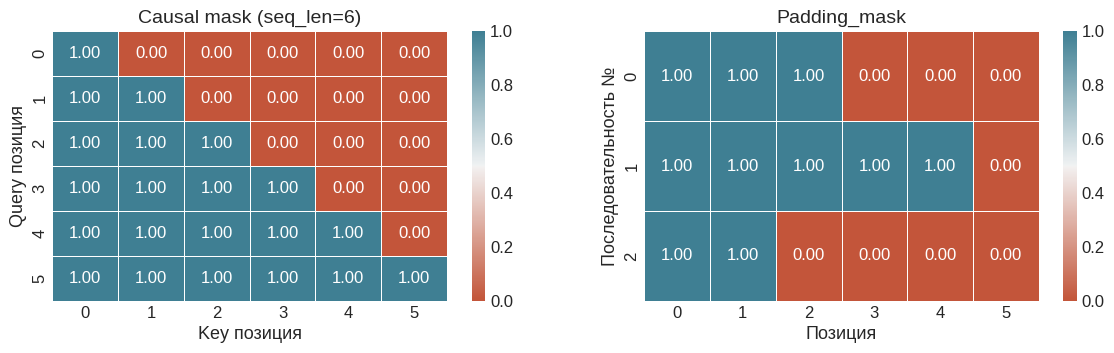

<Figure size 1000x800 with 0 Axes>

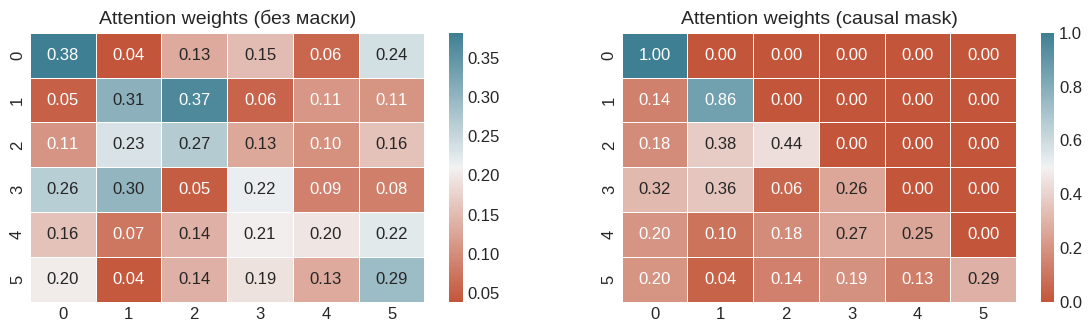

<Figure size 1000x800 with 0 Axes>

Вывод: 

Causal mask обнуляет внимание к будущим позициям,
что необходимо для авторегрессивной генерации.



In [ ]:
# Задача 3. Causal mask и padding mask

def causal_mask(seq_len):
    """Нижнетреугольная маска (1 = разрешено, 0 = запрещено)."""
    mask = torch.ones(seq_len, seq_len)
    mask = torch.tril(mask)
    return mask

def padding_mask(lengths, max_len):
    """Маска для padding: lengths --- длины последовательностей в батче."""
    size_x = len(lengths)
    size_y = max_len
    mask = torch.ones(size_x, size_y)
    for i in range(size_x):
        mask[i, lengths[i]:] = 0
    return mask

# Визуализация масок
#ваш код здесь
seq_len = 6
lengths = [3, 5, 2]
max_len = 6

mask_1 = causal_mask(seq_len)
mask_2 = padding_mask(lengths, max_len)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

plt.figure(figsize=(10, 8))
sns.heatmap(
    mask_1,
    annot=True,
    fmt='.2f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    ax=axes[0]
)
axes[0].set_xlabel('Key позиция', fontsize=13)
axes[0].set_ylabel('Query позиция', fontsize=13)
axes[0].set_title(f'Causal mask (seq_len={seq_len})')

sns.heatmap(
    mask_2,
    annot=True,
    fmt='.2f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    ax=axes[1]
)
axes[1].set_xlabel('Позиция', fontsize=13)
axes[1].set_ylabel('Последовательность №', fontsize=13)
axes[1].set_title(f'Padding_mask')

plt.tight_layout()
plt.show()

# Attention с causal mask и без
#ваш код здесь
torch.manual_seed(42)
Q = torch.randn(1, 6, 7)
K = torch.randn(1, 6, 7)
V = torch.randn(1, 6, 3)

_, w_no_mask = scaled_dot_product_attention(Q, K, V)
_, w_causal  = scaled_dot_product_attention(Q, K, V, mask=mask_1)

fig, axes = plt.subplots(1, 2, figsize=(14, 3.5))

#ваш код здесь
plt.figure(figsize=(10, 8))
sns.heatmap(
    w_no_mask.squeeze(),
    annot=True,
    fmt='.2f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    ax=axes[0]
)
axes[0].set_title('Attention weights (без маски)')

sns.heatmap(
    w_causal.squeeze(),
    annot=True,
    fmt='.2f',
    linewidth=.5,
    cmap=sns.diverging_palette(20, 220, as_cmap=True),
    ax=axes[1]
)
axes[1].set_title('Attention weights (causal mask)')

plt.tight_layout()
plt.show()

print("Вывод: ")
print("""
Causal mask обнуляет внимание к будущим позициям,
что необходимо для авторегрессивной генерации.
""")

---

## Задача 4. Позиционное кодирование

### Постановка задачи

Реализуйте синусоидальное позиционное кодирование и покажите,
что без него attention инвариантен к перестановкам.

### Формулы
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Задача
1. Реализуйте `sinusoidal_pe(max_len, d_model)`.
2. Визуализируйте PE как heatmap.
3. Покажите, что без PE перестановка токенов не меняет attention output.


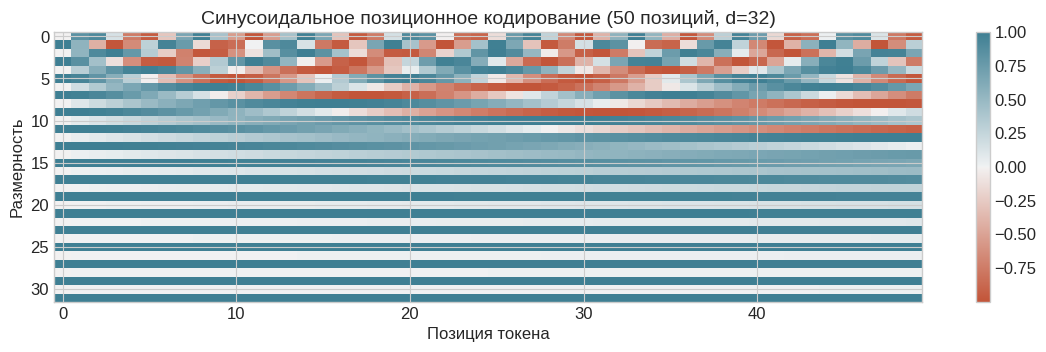

Модуль максимальной разницы элементов без PE: 0.0
Модуль максимальной разницы элементов с PE: 1.6854009628295898


In [ ]:
# Задача 4. Позиционное кодирование

def sinusoidal_pe(max_len, d_model):
    """Синусоидальное позиционное кодирование."""
    p_enc = torch.zeros(max_len, d_model)
    positions = torch.arange(0, max_len).unsqueeze(1)
    # делители в степени -1 для пар позиций
    divizors = 1 / 10000**(torch.arange(0, d_model, 2) / d_model)
    p_enc[:, 0::2] = torch.sin(positions * divizors)
    p_enc[:, 1::2] = torch.cos(positions * divizors)
    return p_enc

# Визуализация
max_len = 50
d_model = 32
pe = sinusoidal_pe(max_len, d_model)

plt.figure(figsize=(14, 3.5))
plt.imshow(pe.T.numpy(), aspect='auto', cmap=sns.diverging_palette(20, 220, as_cmap=True))
plt.xlabel('Позиция токена')
plt.ylabel('Размерность')
plt.title(f'Синусоидальное позиционное кодирование ({max_len} позиций, d={d_model})')
plt.colorbar()
plt.show()


# --- Демонстрация: без PE перестановка не влияет на attention ---
torch.manual_seed(SEED)
d_model = 16
seq_len = 4

# Случайные эмбеддинги (без позиции)
X = torch.randn(seq_len, d_model)

# Прямой порядок
out_orig = X @ X.T

# Перемешиваем токены
# ваш код здесь
mixed_seq = torch.randperm(seq_len)
X_perm = X[mixed_seq]

# Возвращаем исходный порядок для сравнения
inv_perm = torch.argsort(mixed_seq)
#восстановление позиций элементов по обеим осям
out_perm_restored = (X_perm @ X_perm.T)[inv_perm][:, inv_perm]
diff_no_pe = abs(torch.max(out_orig - out_perm_restored).item())
# ваш код здесь
print(f'Модуль максимальной разницы элементов без PE: {diff_no_pe}')

# Теперь с PE
pe_emb = sinusoidal_pe(seq_len, d_model)
X_pe = X + pe_emb
mixed_seq_pe = torch.randperm(seq_len)
inv_perm_pe = torch.argsort(mixed_seq_pe)
X_perm_pe = X_pe[mixed_seq_pe]   # Позиции другие!
out_pe = X_pe @ X.T
out_perm_pe = X_perm_pe @ X_perm_pe.T
out_perm_pe_restored = out_perm_pe[inv_perm_pe][:, inv_perm_pe]
diff_with_pe = abs(torch.max(out_pe - out_perm_pe_restored).item())
# ваш код здесь
print(f'Модуль максимальной разницы элементов с PE: {diff_with_pe}')


**Вывод**:  
Без PE attention инвариантен к перестановкам, а применение PE меняет результат.

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Сборка компонентов Transformer, сравнение с RNN.

## Задача 5. Multi-head attention с нуля

### Постановка задачи

Реализуйте класс `MultiHeadAttention` с нуля (без `nn.MultiheadAttention`).

### Задача
1. `__init__(d_model, n_heads)`: создайте проекции $W_Q, W_K, W_V, W_O$.
2. `forward(x, mask=None)`: split по головам, attention в каждой голове, concat, проекция $W_O$.
3. Проверьте на $d_{model}=32$, $n_{heads}=4$, seq_len=6.
4. Подсчитайте число параметров.


In [ ]:
# Задача 5. Multi-head attention с нуля

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        assert d_model % n_heads == 0, "Количество признаков не соответствует головам"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head = d_model // n_heads

        # Определение проекций, как весов nn.Linear
        # относящихся к данному классу
        # и не имеющих смещений
        self.W_Q = nn.Linear(d_model, d_model, bias=False)
        self.W_K = nn.Linear(d_model, d_model, bias=False)
        self.W_V = nn.Linear(d_model, d_model, bias=False)
        self.W_O = nn.Linear(d_model, d_model, bias=False)

    def params_split(self, x):
        """
        x: (batch, seq_len, d_model)
        Возвращает: (batch, n_heads, seq_len, d_head)
        """
        batch, seq_len, _ = x.shape
        x = x.reshape(batch, seq_len, self.n_heads, self.d_head)
        return x.transpose(1, 2)

    def masking(self, x, mask):
        """
        Маскирование перед softmax
        x: (batch, n_heads, seq_len, seq_len)
        """
        assert mask.dim() == 3, "Маска должна быть трёхмерной"
        mask = mask.unsqueeze(1) # чтобы применять на несколько голов
        return x.masked_fill(mask == 0, -1e9)


    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) или None
        """
        batch, seq_len, d_model = x.shape
        Q = self.W_Q(x)
        Q_h = self.params_split(Q)
        K = self.W_K(x)
        K_h = self.params_split(K)
        V = self.W_V(x)
        V_h = self.params_split(V)

        scaling = torch.matmul(Q_h, K_h.transpose(-2, -1)) / math.sqrt(self.d_head)
        if mask is not None:
            scaling = self.masking(scaling, mask)

        weights = F.softmax(scaling, dim=-1)
        output = torch.matmul(weights, V_h)

        # Объединение результатов голов
        # взаимная перестановка n_heads и seq_len
        output = output.transpose(1, 2)
        # объединение
        output = output.reshape(batch, seq_len, d_model)

        output = self.W_O(output)

        return output, weights


# --- Тестирование ---
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(2, 6, d_model)
output, weights = mha(x)

print(f"Вход:     {x.shape}")
print(f"Выход:    {output.shape}")
print(f"Веса:     {weights.shape}  (batch, n_heads, seq_q, seq_k)")
print()

total_params = sum(p.numel() for p in mha.parameters())
print(f"Число параметров MHA: {total_params:,}")
print(f"  W_Q: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_K: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_V: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_O: {d_model}x{d_model} = {d_model*d_model}")
print(f"  Итого: 4 * {d_model}^2 = {4*d_model*d_model}")

# Проверка формы

Вход:     torch.Size([2, 6, 32])
Выход:    torch.Size([2, 6, 32])
Веса:     torch.Size([2, 4, 6, 6])  (batch, n_heads, seq_q, seq_k)

Число параметров MHA: 4,096
  W_Q: 32x32 = 1024
  W_K: 32x32 = 1024
  W_V: 32x32 = 1024
  W_O: 32x32 = 1024
  Итого: 4 * 32^2 = 4096


**Вывод:**  
Форма выхода совпадает с формой входа.

---

## Задача 6. Сборка Transformer Encoder Layer

### Постановка задачи

Реализуйте один слой Transformer Encoder с нуля.

### Структура (post-norm)
```
x -> MHA -> Add(x) -> LayerNorm -> FFN -> Add -> LayerNorm -> output
```

### Задача
1. Используйте `MultiHeadAttention` из задачи 5.
2. FFN: $\text{Linear}(d_{model}, d_{ff}) \to \text{ReLU} \to \text{Linear}(d_{ff}, d_{model})$.
3. $d_{model}=64$, $n_{heads}=4$, $d_{ff}=256$.
4. Проверьте: output.shape == input.shape.
5. Подсчитайте число параметров.


In [ ]:
# Задача 6. Transformer Encoder Layer

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, n_heads)
        self.drop_resid_con = nn.Dropout(dropout)
        self.ffn_seq = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Linear(d_ff, d_model),
        )
        self.lay_norm1 = nn.LayerNorm(d_model)
        self.lay_norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        # Self-attention + residual + norm (post-norm)
        # ваш код здесь
        cur_output, cur_weights = self.mha(x, mask=mask)
        x = self.lay_norm1(x + self.drop_resid_con(cur_output))

        # FFN + residual + norm
        ffn_result = self.ffn_seq(x)
        x = self.lay_norm2(x + self.drop_resid_con(ffn_result))

        return x, cur_weights

# --- Тестирование ---
d_model, n_heads, d_ff = 64, 4, 256
enc_layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output, weights = enc_layer(x)

print(f"Вход:  {x.shape}")
print(f"Выход: {output.shape}")
assert output.shape == x.shape, "Форма должна сохраняться!"
print("[OK] Форма сохраняется.")
print()

# Подсчет параметров
# ваш код здесь
total = sum(p.numel() for p in enc_layer.parameters())
mha_p = sum(p.numel() for p in enc_layer.mha.parameters())
ffn_p = sum(p.numel() for p in enc_layer.ffn_seq.parameters())
norm_p = sum(p.numel() for p in enc_layer.lay_norm1.parameters()) +\
    sum(p.numel() for p in enc_layer.lay_norm2.parameters())

print(f"Параметры Transformer Encoder Layer:")
print(f"  MHA:       {mha_p}")
print(f"  FFN:       {ffn_p}")
print(f"  LayerNorm: {norm_p}")
print(f"  ИТОГО:     {total}")


Вход:  torch.Size([2, 10, 64])
Выход: torch.Size([2, 10, 64])
[OK] Форма сохраняется.

Параметры Transformer Encoder Layer:
  MHA:       16384
  FFN:       33088
  LayerNorm: 256
  ИТОГО:     49728


---

## Задача 7. RNN vs Transformer: дальние зависимости

### Постановка задачи

Сравните RNN и Transformer на синтетической задаче,
требующей «запоминания» начала длинной последовательности.

### Задача
Последовательность из 0 и 1 длиной 50. Задача: определить,
совпадают ли первый и последний элементы (бинарная классификация).

1. Реализуйте RNN-классификатор (GRU + Linear).
2. Реализуйте Transformer-классификатор (2 Encoder слоя + mean pooling + Linear).
3. Обучите оба на 2000 train / 500 test, 20 эпох.
4. Сравните test accuracy.


Train: torch.Size([2000, 50, 1]), Test: torch.Size([500, 50, 1])
Баланс классов (train): 0.485
RNN (GRU) эпоха 5/20  test_acc=0.4640
RNN (GRU) эпоха 10/20  test_acc=0.4760
RNN (GRU) эпоха 15/20  test_acc=0.4640
RNN (GRU) эпоха 20/20  test_acc=0.4800
Transformer эпоха 5/20  test_acc=0.4780
Transformer эпоха 10/20  test_acc=0.4720
Transformer эпоха 15/20  test_acc=0.4740
Transformer эпоха 20/20  test_acc=0.4520


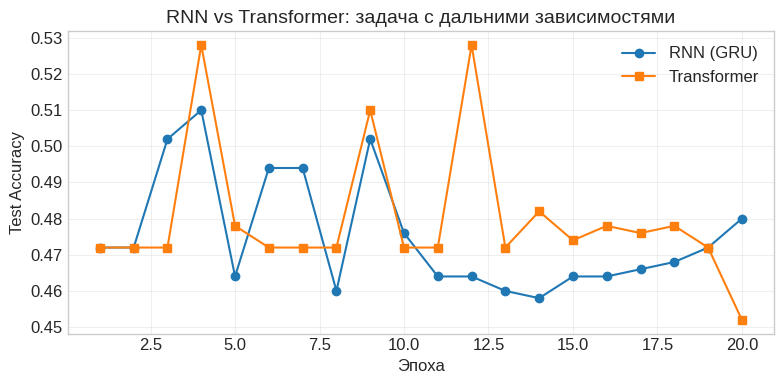


Итоговая accuracy:
  RNN (GRU):      0.4800
  Transformer:    0.4520


In [ ]:
# Задача 7. RNN vs Transformer

torch.manual_seed(SEED)
np.random.seed(SEED)

SEQ_LEN = 50

def generate_first_last_data(n, seq_len=SEQ_LEN):
    """Генерация: label = 1, если первый и последний элементы совпадают."""
    X = torch.randint(0, 2, (n, seq_len)).float()
    X = X.unsqueeze(-1)
    y = (X[:, 0] == X[:, -1]).long().squeeze(-1)
    return X, y

# ваш код здесь
X_train, y_train = generate_first_last_data(2000)
X_test, y_test   = generate_first_last_data(500)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов (train): {y_train.float().mean():.3f}")

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test), batch_size=32)

# --- RNN-классификатор ---
class RNNClassifier(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=32, n_layers=1):
        super().__init__()
        self.rnn = nn.GRU(input_dim, hidden_dim, n_layers, batch_first=True)
        self.head = nn.Linear(hidden_dim, 2)

    def forward(self, x):
        _, h_n = self.rnn(x)
        return self.head(h_n[-1])

# --- Transformer-классификатор ---
class TransformerClassifier(nn.Module):
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, seq_len=SEQ_LEN):
        super().__init__()
        self.lin_lay = nn.Linear(input_dim, d_model)
        self.pe = sinusoidal_pe(SEQ_LEN, d_model)
        self.transf_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.head = nn.Linear(d_model, 2)

    def forward(self, x):
        x = self.lin_lay(x) + self.pe[: x.size(1)].to(x.device)
        for layer in self.transf_layers:
            x, _ = layer(x)
        pooling = x.mean(dim=1)
        return self.head(pooling)

epoch_to_show = [5, 10, 15, 20]
def train_classifier(model, name, train_loader, test_loader, epochs=20, lr=1e-3):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    accuracy_test_lst = []
    for epoch in range(1, epochs + 1):
        model.train()
        for x_train, y_train in train_loader:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
            logits = model(x_train)
            loss = loss_fn(logits, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # Тестовая accuracy
        model.eval()
        right_sum = 0
        total = 0
        with torch.no_grad():
            for x_test, y_test in test_loader:
                x_test = x_test.to(device)
                y_test = y_test.to(device)
                logits = model(x_test)
                # выбор более вероятного класса
                test_preds = logits.argmax(dim=-1)

                right_sum += (test_preds == y_test).sum().item()
                total += y_test.numel()
        accuracy_test = right_sum / total
        accuracy_test_lst.append(accuracy_test)

        if epoch in epoch_to_show:
            print(f'{name} эпоха {epoch}/20  test_acc={accuracy_test:.4f}')
    return accuracy_test_lst


#ваш код здесь
model_rnn = RNNClassifier(input_dim=1, hidden_dim=32)
model_tr = TransformerClassifier(input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2, seq_len=SEQ_LEN)

rnn_accs = train_classifier(model_rnn, 'RNN (GRU)', train_loader, test_loader, epochs=20, lr=1e-3)
tr_accs = train_classifier(model_tr, 'Transformer', train_loader, test_loader, epochs=20, lr=1e-3)


plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), rnn_accs, 'o-', label='RNN (GRU)')
plt.plot(range(1, 21), tr_accs, 's-', label='Transformer')
plt.xlabel('Эпоха'); plt.ylabel('Test Accuracy')
plt.title('RNN vs Transformer: задача с дальними зависимостями')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"\nИтоговая accuracy:")
#ваш код здесь
print(f"  RNN (GRU):      {rnn_accs[-1]:.4f}")
print(f"  Transformer:    {tr_accs[-1]:.4f}")

---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Языковая модель и анализ attention.

## Задача 8. Мини decoder-only Transformer (char-level LM)

### Постановка задачи

Реализуйте маленькую авторегрессивную языковую модель на уровне символов.

### Задача
1. Определите корпус текста (несколько предложений на русском).
2. Постройте словарь символов.
3. Реализуйте decoder-only Transformer: embedding + PE + 2 decoder слоя + LM head.
4. Обучите модель с causal mask.
5. Сгенерируйте текст авторегрессивно.


 Эпоха 10/20  loss=0.7458
 Эпоха 20/20  loss=0.3111
 Эпоха 30/20  loss=0.2191
 Эпоха 40/20  loss=0.1827
 Эпоха 50/20  loss=0.1604


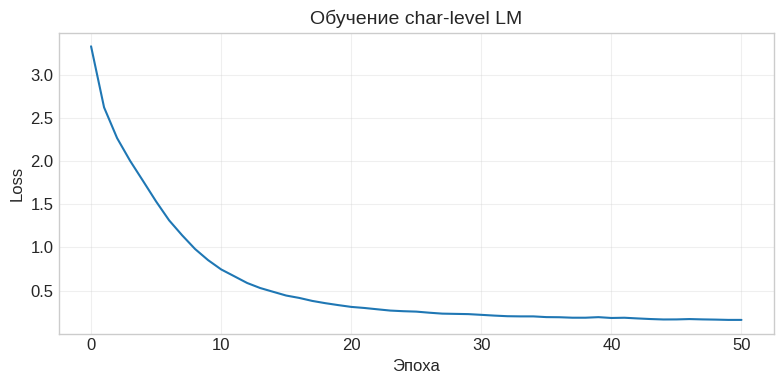

Длина корпуса: 725 символов
Размер словаря: 51
Обучающих примеров: 693

--- Сгенерированный текст (temperature=0.8) ---
Нейронные сети представляют собощныченых выхого ино выхо итеногулязыча. Языкци прь преляетретобучени во моых месих в. Язых манитететететеки пр ски ски прошибучес позволяесизво эффффетийоктивля декть ктьслектьстатьст


In [ ]:
# Задача 8. Мини decoder-only Transformer

torch.manual_seed(SEED)

# --- Корпус ---
corpus = (
    "Нейронные сети представляют собой мощный инструмент машинного обучения. "
    "Глубокое обучение позволяет автоматически извлекать признаки из данных. "
    "Архитектура Transformer произвела революцию в обработке естественного языка. "
    "Механизм внимания позволяет модели фокусироваться на релевантных частях входа. "
    "Языковые модели предсказывают следующий токен на основе контекста. "
    "Обучение нейронных сетей требует больших объемов данных и вычислительных ресурсов. "
    "Регуляризация помогает избежать переобучения модели на тренировочных данных. "
    "Функция потерь определяет качество предсказаний модели. "
    "Градиентный спуск является основным методом оптимизации параметров. "
    "Обратное распространение ошибки позволяет эффективно вычислять градиенты. "
)

# --- Токенизация (char-level) ---
chars = sorted(list(set(corpus)))
vocab_size = len(chars)
# для кодирования
str_to_ind = {ch: i for i, ch in enumerate(chars)}
ind_to_str = {i: ch for ch, i in str_to_ind.items()}

# кодирование корпуса
corpus_cod = torch.tensor([str_to_ind[ch] for ch in corpus], dtype=torch.long)

# --- Подготовка данных ---
CONTEXT_LEN = 32

def make_sequences(data, ctx_len):
    """
    Функция создаёт из data набор входных (X) и
    выходных (Y) последовательностей, каждая длиной ctx_len,
    где ctx_len - окно, скользящее с единичным шагом.

    Возвращает X, Y:
    X: (wind_cnt, ctx_len) - вход токен
    Y: (wind_cnt, ctx_len) - следующий токен (таргет)
    """
    char_cnt = data.size(0)
    if char_cnt <= ctx_len:
        X, Y = (
            torch.empty(0, ctx_len, dtype=torch.long),
            torch.empty(0, ctx_len, dtype=torch.long)
        )
        return X, Y
    X_lst = []
    Y_lst = []
    wind_cnt = char_cnt - ctx_len # возможное количество окон
    for i in range(wind_cnt):
        x = data[i : i + ctx_len]
        y = data[i + 1 : i + ctx_len + 1]
        X_lst.append(x.unsqueeze(0))
        Y_lst.append(y.unsqueeze(0))
    X = torch.cat(X_lst, dim=0)
    Y = torch.cat(Y_lst, dim=0)
    return X, Y


X_lm, Y_lm = make_sequences(corpus_cod, CONTEXT_LEN)

batch_size = 32
lm_loader = DataLoader(TensorDataset(X_lm, Y_lm), batch_size=batch_size, shuffle=True)

# --- Decoder-only Transformer ---
class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, d_ff=128, n_layers=2, max_len=128):
        super().__init__()
        self.d_model = d_model
        # чтобы получить размерность batch х seq х d_model
        self.token_embed = nn.Embedding(vocab_size, d_model)
        # PE сохраняется как buffer, чтобы не оптимизировался
        self.register_buffer('pe', sinusoidal_pe(max_len, d_model))
        self.transf_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.final_out = nn.Linear(d_model, vocab_size)

    def forward(self, x):
        _, input_len = x.shape
        # масштабирование токенов для стабилизации
        x = self.token_embed(x) * math.sqrt(self.d_model)
        x = x + self.pe[:input_len].to(x.device)
        # маска для токенов
        mask = torch.tril(torch.ones(input_len, input_len, dtype=torch.int, device=x.device))
        mask = mask.unsqueeze(0)

        lay_weights_lst = [] # Список весов слоёв для задания 9
        for layer in self.transf_layers:
            x, attn_weights = layer(x, mask=mask)
            lay_weights_lst.append(attn_weights)
        logits = self.final_out(x)
        lay_weights_lst = torch.stack(lay_weights_lst, dim=0)
        # выходная размерность логитов batch х seq х vocab_size
        return logits, lay_weights_lst

model_lm = CharTransformerLM(vocab_size).to(device)
optimizer = optim.Adam(model_lm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# --- Обучение ---
lm_losses = []
# ваш код здесь
epochs = 50
epoch_to_show = [10, 20, 30, 40, 50]
for epoch in range(epochs + 1):
    model_lm.train()
    accum_loss = 0
    x_cnt = 0
    for x_train, y_train in lm_loader:
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        logits, _ = model_lm(x_train)
        # Выпрямление логитов и таргетов для CrossEntropyLoss
        flat_log= logits.reshape(-1, vocab_size)
        flat_target = y_train.reshape(-1)
        loss = criterion(flat_log, flat_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accum_loss += loss.item() * x_train.size(0)
        x_cnt += x_train.size(0)

    mean_loss = accum_loss / x_cnt
    lm_losses.append(mean_loss)
    if epoch in epoch_to_show:
            print(f' Эпоха {epoch}/20  loss={mean_loss:.4f}')


plt.figure(figsize=(8, 4))
plt.plot(lm_losses)
plt.xlabel('Эпоха'); plt.ylabel('Loss')
plt.title('Обучение char-level LM'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

# --- Генерация текста ---
def generate_text(model, seed_text, length=150, temperature=1.0):
    model.eval()
    with torch.no_grad():
        # Исходные токены
        new_text_cod = [str_to_ind.get(ch, 0) for ch in seed_text]

        for _ in range(length):
            # последние CONTEXT_LEN токенов
            input_tenz = torch.tensor(
                new_text_cod[-CONTEXT_LEN:],
                dtype=torch.long, device=device
            ).unsqueeze(0)

            logits, _ = model(input_tenz)
            # логиты для последней позиции
            # с поправкой на температуру
            if temperature > 0:
                last_pos_logits = logits[0, -1, :] / temperature
            else:
                last_pos_logits = logits[0, -1, :]

            probs = F.softmax(last_pos_logits, dim=-1)

            # индекс нового токена с учётом температуры
            new_char_id = int(torch.multinomial(probs, num_samples=1).item())
            new_text_cod.append(new_char_id)

        return ''.join(ind_to_str[i] for i in new_text_cod)

print(f'Длина корпуса: {len(corpus_cod)} символов')
print(f'Размер словаря: {vocab_size}')
print(f'Обучающих примеров: {X_lm.shape[0]}')

print("\n--- Сгенерированный текст (temperature=0.8) ---")
seed = "Нейронные сети "
print(generate_text(model_lm, seed, length=200, temperature=0.8))

---

## Задача 9. Визуализация attention и стратегии декодирования

### Постановка задачи

Используя модель из задачи 8, визуализируйте матрицы внимания
и сравните разные стратегии генерации текста.

### Задача
1. Извлеките и визуализируйте attention weights для 2—3 голов.
2. Реализуйте три стратегии декодирования: greedy, temperature, top-k.
3. Сгенерируйте текст каждой стратегией и сравните результаты.


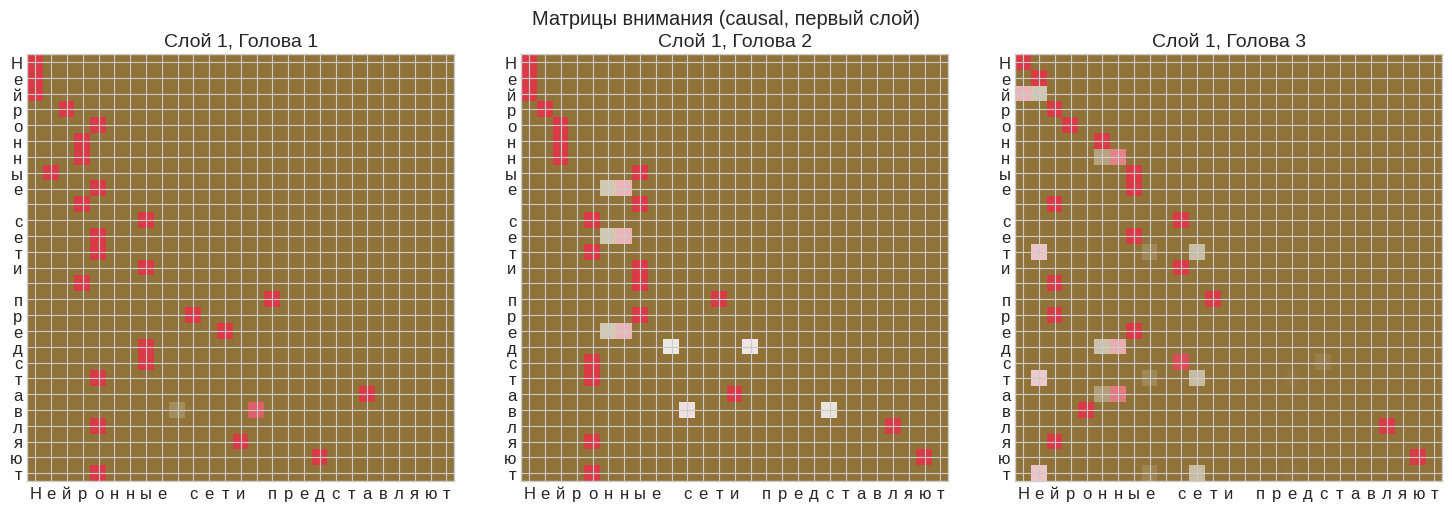

GREEDY:
Глубокое обучение позволяет автоматически извлекать признаки из из данных. Архитектура Transformer произвела революцию в обработке естестественного языка. Механизм вним

TEMPERATURE = 0.5 (более детерминированный):
Глубокое обучение позволяет автоматически извлекать признаки из из данных. Архитектура Transformer произвела революцию в обработке естестественного языка. Механизм вним

TEMPERATURE = 1.5 (более случайный):
Глубокое обучение позвляет автокетавтототь ескулеканое превазаниреван реваконя измоли избе . МАризвозвеханнаных гла. ктехитенетет р ora ри рх Tranода оивыermer па паи п

TOP-K (k=5):
Глубокое обучение позволяет автоматически извлекекать признаки из из даннных. Архитектектура Transformer произвела революцию в обработкеть естестественного языка. Механ

TOP-K (k=3):
Глубокое обучение позволяет автоматически извлеки признаки и из дантоных. Араных. Архитектектектура Transformer произвела революцию в обработкеоте естественнного языка.



In [ ]:
# Задача 9. Визуализация attention и стратегии декодирования

# --- Визуализация attention ---
model_lm.eval()
sample_text = "Нейронные сети представляют"
sample_ids = [str_to_ind.get(ch, 0) for ch in sample_text]
sample_ids = torch.tensor(
    sample_ids[-CONTEXT_LEN:],
    dtype=torch.long, device=device
).unsqueeze(0)


with torch.no_grad():
     _, attn_all = model_lm(sample_ids)

# attn_all[layer]: (B, n_heads, seq, seq)
# Веса первого слоя - слой 0, батч 0
layer_1_attn = attn_all[0, 0]

n_show_heads = 3
fig, axes = plt.subplots(1, n_show_heads, figsize=(5 * n_show_heads, 5))
symbols = list(sample_text)
symbols_len = len(symbols)

for h_idx in range(n_show_heads):
    h_weights = layer_1_attn[h_idx].cpu().numpy()
    axes[h_idx].imshow(
        h_weights,
        cmap=sns.diverging_palette(60, 10, as_cmap=True)
    )
    axes[h_idx].set_title(f'Слой 1, Голова {h_idx+1}')
    axes[h_idx].set_xticks(range(symbols_len))
    axes[h_idx].set_xticklabels(symbols)
    axes[h_idx].set_yticks(range(symbols_len))
    axes[h_idx].set_yticklabels(symbols)

plt.suptitle('Матрицы внимания (causal, первый слой)')
plt.tight_layout(); plt.show()

# --- Стратегии декодирования ---
def generate_greedy(model, seed_text, length=100):
    """Жадное декодирование: всегда выбирается argmax."""
    model.eval()

    with torch.no_grad():
        # Исходные токены
        new_text_cod = [str_to_ind.get(ch, 0) for ch in seed_text]
        for _ in range(length):

            # последние CONTEXT_LEN токенов
            input_tenz = torch.tensor(
                new_text_cod[-CONTEXT_LEN:],
                dtype=torch.long, device=device
            ).unsqueeze(0)

            logits, _ = model(input_tenz)
            last_pos_logits = logits[0, -1, :]
            probs = F.softmax(last_pos_logits, dim=-1)

            # индекс нового токена
            new_char_id = torch.argmax(probs).item()
            new_text_cod.append(new_char_id)

        return ''.join(ind_to_str[i] for i in new_text_cod)


def generate_temperature(model, seed_text, length=100, temperature=1.0):
    """Сэмплирование с температурой."""
    with torch.no_grad():
        # Исходные токены
        new_text_cod = [str_to_ind.get(ch, 0) for ch in seed_text]
        for _ in range(length):

            # последние CONTEXT_LEN токенов
            input_tenz = torch.tensor(
                new_text_cod[-CONTEXT_LEN:],
                dtype=torch.long, device=device
            ).unsqueeze(0)

            logits, _ = model(input_tenz)
            # с поправкой на температуру
            if temperature > 0:
                last_pos_logits = logits[0, -1, :] / temperature
            else:
                last_pos_logits = logits[0, -1, :]
            probs = F.softmax(last_pos_logits, dim=-1)

            # индекс нового токена с учётом температуры
            new_char_id = int(torch.multinomial(probs, num_samples=1).item())
            new_text_cod.append(new_char_id)

        return ''.join(ind_to_str[i] for i in new_text_cod)


def generate_top_k(model, seed_text, length=100, k=5, temperature=1.0):
    """Top-k сэмплирование."""
    with torch.no_grad():
        # Исходные токены
        new_text_cod = [str_to_ind.get(ch, 0) for ch in seed_text]
        for _ in range(length):

            # последние CONTEXT_LEN токенов
            input_tenz = torch.tensor(
                new_text_cod[-CONTEXT_LEN:],
                dtype=torch.long, device=device
            ).unsqueeze(0)

            logits, _ = model(input_tenz)
            last_pos_logits = logits[0, -1, :]
            probs = F.softmax(last_pos_logits, dim=-1)

            if temperature == 0 or k == 1:
                new_char_id = int(torch.argmax(probs).item())
            else:
                last_pos_logits = logits[0, -1, :] / temperature
                # Топ-k  логитов и их индексы
                top_k_logits, top_k_indices = torch.topk(last_pos_logits, k=k)
                probs = F.softmax(top_k_logits, dim=-1)
                # Индекс следующего токена по top_k_indices
                next_ind_top_k = torch.multinomial(probs, num_samples=1).item()
                # Индекс токена по общей нумерации
                new_char_id = int(top_k_indices[next_ind_top_k].item())
                new_text_cod.append(new_char_id)

        return ''.join(ind_to_str[i] for i in new_text_cod)


seed = "Глубокое обучение "


print("=" * 60)
print("GREEDY:")
print(generate_greedy(model_lm, seed, 150))
print()

print("=" * 60)
print("TEMPERATURE = 0.5 (более детерминированный):")
print(generate_temperature(model_lm, seed, 150, temperature=0.5))
print()

print("=" * 60)
print("TEMPERATURE = 1.5 (более случайный):")
print(generate_temperature(model_lm, seed, 150, temperature=1.5))
print()

print("=" * 60)
print("TOP-K (k=5):")
print(generate_top_k(model_lm, seed, 150, k=5))
print()

print("=" * 60)
print("TOP-K (k=3):")
print(generate_top_k(model_lm, seed, 150, k=3))
print()

  **Анализ:**  
  * Greedy: наиболее детерминированный, часто зацикливается.  
  * Низкая температура: близко к greedy, но с небольшой вариативностью.  
  * Высокая температура: более разнообразный, но менее когерентный текст.  
  * Top-k: ограничивает выбор k наиболее вероятных символов, баланс между разнообразием и качеством.